In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import imagehash
from PIL import Image

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(ROOT))

from Utils.project_utils import get_project_root

In [3]:
PROJECT_ROOT = get_project_root()
CLASSES_DIR = PROJECT_ROOT / "Classes"
DATA_DIR = PROJECT_ROOT / "Data"

### EDA

In [4]:
df = pd.read_csv(DATA_DIR / "mushroomDetailedPaths.csv")

#### Basic Quality Checks

In [5]:
df.head(), df.shape

(                                    file_path  depth file_name file_ext  \
 0   conditionally_edible/horn_of_plenty/8.png      3         8      png   
 1   conditionally_edible/horn_of_plenty/9.png      3         9      png   
 2  conditionally_edible/horn_of_plenty/14.png      3        14      png   
 3  conditionally_edible/horn_of_plenty/12.png      3        12      png   
 4  conditionally_edible/horn_of_plenty/13.png      3        13      png   
 
    width  height  num_pixels             phash  aspect_ratio  \
 0    512     512      262144  abb9d4a0aae5c4d4           1.0   
 1    512     512      262144  a581b66e5c2d6b32           1.0   
 2    512     512      262144  d8f40799f31ea870           1.0   
 3    512     512      262144  a8a8e950d4af3f58           1.0   
 4    512     512      262144  8e86638cdcad5bd0           1.0   
 
                   class         species  
 0  conditionally_edible  horn_of_plenty  
 1  conditionally_edible  horn_of_plenty  
 2  conditionally_edi

In [6]:
# Completeness / quality
print("Missing values per column:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nUnique classes:", df["class"].nunique())
print("Unique species:", df["species"].nunique())
print("File ext counts:\n", df["file_ext"].value_counts().head())

Missing values per column:


file_path       0
depth           0
file_name       0
file_ext        0
width           0
height          0
num_pixels      0
phash           0
aspect_ratio    0
class           0
dtype: int64


Unique classes: 4
Unique species: 570
File ext counts:
 file_ext
jpg     45578
jpeg    45163
png     11959
JPG        11
Name: count, dtype: int64


#### Class Distribution Plot

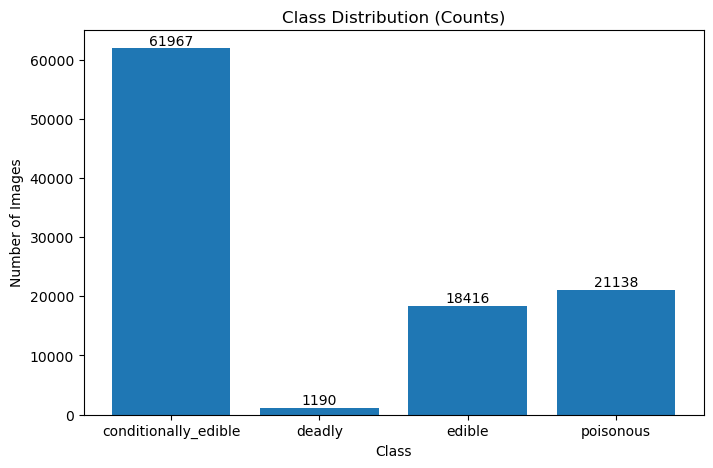

In [7]:
counts = df["class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values)

plt.title("Class Distribution (Counts)")
plt.xlabel("Class")
plt.ylabel("Number of Images")

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.show()

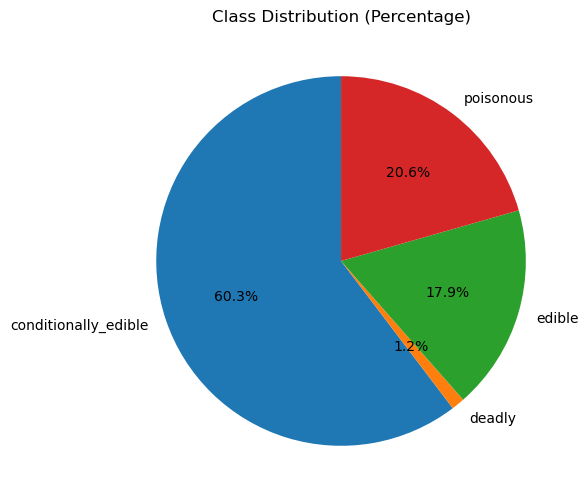

In [8]:
plt.figure(figsize=(6, 6))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution (Percentage)")
plt.show()

In [9]:
class_dist_table = (
    counts
    .rename("count")
    .to_frame()
)

class_dist_table["percentage"] = (
    class_dist_table["count"] / class_dist_table["count"].sum() * 100
).round(2)

class_dist_table


,count,percentage
class,,
conditionally_edible,61967,60.33
deadly,1190,1.16
edible,18416,17.93
poisonous,21138,20.58


#### Image Size / Resolution distribution

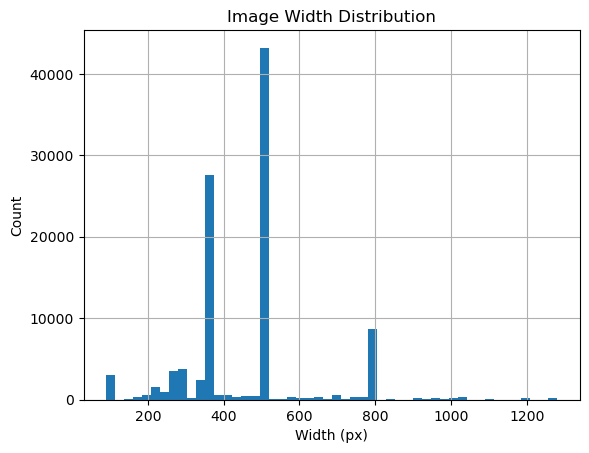

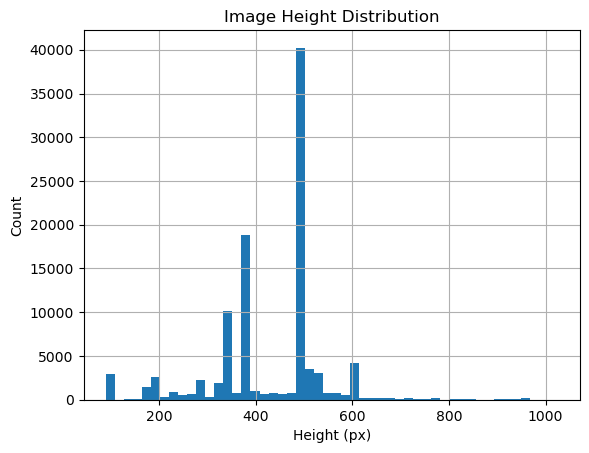

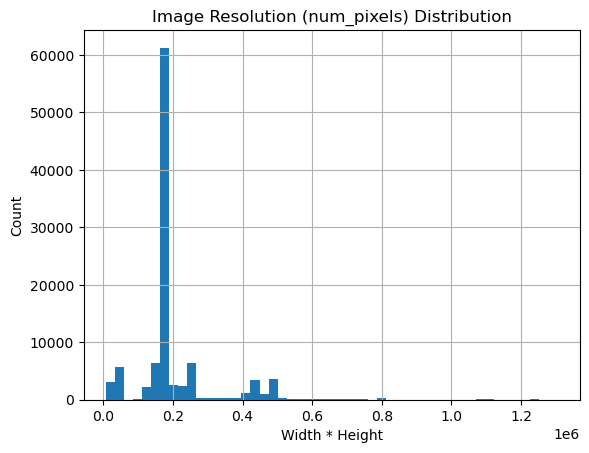

In [10]:
plt.figure()
df["width"].hist(bins=50)
plt.title("Image Width Distribution")
plt.xlabel("Width (px)")
plt.ylabel("Count")
plt.show()

plt.figure()
df["height"].hist(bins=50)
plt.title("Image Height Distribution")
plt.xlabel("Height (px)")
plt.ylabel("Count")
plt.show()

plt.figure()
df["num_pixels"].hist(bins=50)
plt.title("Image Resolution (num_pixels) Distribution")
plt.xlabel("Width * Height")
plt.ylabel("Count")
plt.show()

#### Aspect Ratio + Scatter (spot outliers)

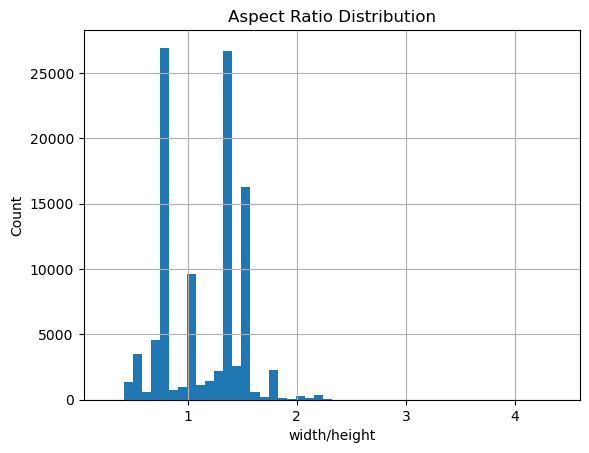

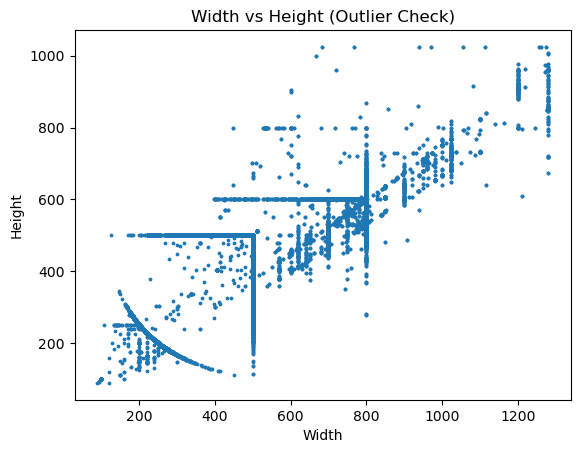

In [11]:
plt.figure()
df["aspect_ratio"].hist(bins=50)
plt.title("Aspect Ratio Distribution")
plt.xlabel("width/height")
plt.ylabel("Count")
plt.show()

# Spot weird sizes/outliers
plt.figure()
plt.scatter(df["width"], df["height"], s=3)
plt.title("Width vs Height (Outlier Check)")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()


#### Duplicate Check (Exact and Near)

Duplicate and near-duplicate images were identified and removed to reduce redundancy and prevent df leakage between training and evaluation sets.

##### Exact Duplicate Removal
- Perceptual hash (pHash) values were used to identify exact duplicate images.
- Images sharing the same pHash were considered visually identical.
- For each group of exact duplicates, only the image with the highest resolution (largest number of pixels) was retained.
- Lower-resolution duplicates were removed from the dataset.

In [12]:
df_sorted = df.sort_values(["phash", "num_pixels"], ascending=[True, False])

exact_dedup = df_sorted.drop_duplicates(subset=["phash"], keep="first").copy().reset_index(drop=True)

removed = len(df) - len(exact_dedup)
print(f"Rows before: {len(df):,}")
print(f"Rows after : {len(exact_dedup):,}")
print(f"Removed    : {removed:,} ({removed/len(df)*100:.2f}%)")

exact_dedup.to_csv(DATA_DIR / "mushroomDedupExact.csv", index=False)
print("Saved:", "mushroomDedupExact.csv")

Rows before: 102,711
Rows after : 94,697
Removed    : 8,014 (7.80%)
Saved: mushroomDedupExact.csv


##### Near-Duplicate Removal
- Near-duplicate images were identified by computing the Hamming distance between pHash values.
- Images with a Hamming distance below a predefined threshold were considered near-duplicates.
- When near-duplicate images were detected, the image with the highest resolution was retained, and remaining lower-resolution images were removed.

In [13]:
HAMMING_THRESHOLD = 5     # 5 means "very similar"
PREFIX_LEN = 4            # bucket by first 4 hex chars; increase to reduce comparisons

In [14]:
# Convert to ImageHash
hashes = df["phash"].astype(str).apply(imagehash.hex_to_hash)

In [15]:
# Bucket indices by hash prefix to avoid O(N^2)
buckets = defaultdict(list)
for i, h in enumerate(hashes):
    buckets[str(h)[:PREFIX_LEN]].append(i)

keep = set(range(len(df)))
dropped = set()

In [16]:
# Within each bucket, drop near-duplicates by keeping highest resolution
for _, idxs in buckets.items():
    if len(idxs) <= 1:
        continue

    idxs_sorted = sorted(idxs, key=lambda i: df.loc[i, "num_pixels"], reverse=True)

    chosen = []
    for i in idxs_sorted:
        if i in dropped:
            continue
        is_near_dup = any((hashes[i] - hashes[j]) <= HAMMING_THRESHOLD for j in chosen)
        if is_near_dup:
            dropped.add(i)
        else:
            chosen.append(i)

In [17]:
keep = sorted(list(keep - dropped))
near_dedup = df.iloc[keep].copy().reset_index(drop=True)

print(f"Rows before: {len(df):,}")
print(f"Rows after : {len(near_dedup):,}")
print(f"Removed    : {len(df)-len(near_dedup):,} ({(len(df)-len(near_dedup))/len(df)*100:.2f}%)")

near_dedup.to_csv(DATA_DIR / "mushroomDedupNear.csv", index=False)
print("Saved:", "mushroomDedupNear.csv")

Rows before: 102,711
Rows after : 94,631
Removed    : 8,080 (7.87%)
Saved: mushroomDedupNear.csv


In [18]:
# BASE_DIR = Path(".") 

print("raw :", df.shape)
print("exact:", exact_dedup.shape)
print("near :", near_dedup.shape)

raw : (102711, 11)
exact: (94697, 11)
near : (94631, 11)


##### Stat after Deduplication

In [19]:
def exact_dup_stats(df):
    vc = df["phash"].astype(str).value_counts()
    dup_hashes = (vc > 1).sum()
    dup_images = vc[vc > 1].sum()
    return dup_hashes, dup_images

rows = []
for name, d in [("raw", df), ("after_exact", exact_dedup), ("after_near", near_dedup)]:
    dup_hashes, dup_images = exact_dup_stats(d)
    rows.append({
        "dataset": name,
        "n_rows": len(d),
        "hashes_with_count>1": dup_hashes,
        "images_in_exact_dup_groups": int(dup_images),
        "exact_dup_rate": float(dup_images / len(d))
    })

summary = pd.DataFrame(rows)
summary


,dataset,n_rows,hashes_with_count>1,images_in_exact_dup_groups,exact_dup_rate
0,raw,102711,7622,15636,0.152233
1,after_exact,94697,0,0,0.000000
2,after_near,94631,0,0,0.000000


##### Sample of Exact Duplicates Removed

In [20]:
def show_exact_duplicate_group(df, base_dir=CLASSES_DIR, max_show=6):
    # Count pHash occurrences
    vc = df["phash"].astype(str).value_counts()
    dup_hashes = vc[vc > 1]

    if len(dup_hashes) == 0:
        print("No exact duplicates found.")
        return

    # Take the first duplicate hash as an example
    ph = dup_hashes.index[0]
    group = df[df["phash"].astype(str) == ph].copy()

    # Keep highest-resolution images first
    group = group.sort_values("num_pixels", ascending=False).head(max_show)

    print(f"Example exact-duplicate pHash: {ph}")
    display(group[["file_path", "width", "height", "num_pixels", "class", "species"]])

    plt.figure(figsize=(14, 3))
    for i, (_, row) in enumerate(group.iterrows(), start=1):
        img_path = (base_dir / row["file_path"]).resolve()

        if not img_path.exists():
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, len(group), i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f'{row["width"]}×{row["height"]}')

    plt.show()


Example exact-duplicate pHash: 965a79b4423b7266


,file_path,width,height,num_pixels,class,species
68621,poisonous/Amanita_roseotincta/Amanita_roseotin...,100,100,10000,poisonous,Amanita_roseotincta
73590,poisonous/Amanita_neoovoidea/Amanita_neoovoide...,100,100,10000,poisonous,Amanita_neoovoidea
73618,poisonous/Amanita_parvipantherina/Amanita_parv...,100,100,10000,poisonous,Amanita_parvipantherina
73776,poisonous/Amanita_ibotengutake/Amanita_iboteng...,100,100,10000,poisonous,Amanita_ibotengutake
73825,poisonous/Amanita_smithiana/Amanita_smithiana2...,100,100,10000,poisonous,Amanita_smithiana
74007,poisonous/Amanita_petalinivolva/Amanita_petali...,100,100,10000,poisonous,Amanita_petalinivolva


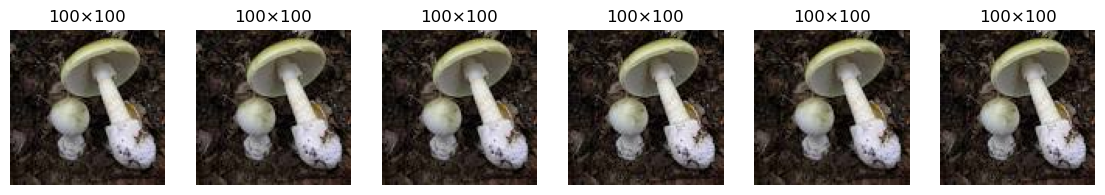

In [23]:
show_exact_duplicate_group(df)

##### Sample of Near Duplicates Removed

In [24]:

def hamming_hex(h1, h2):
    # robust popcount (works on older Python too)
    x = int(h1, 16) ^ int(h2, 16)
    return bin(x).count("1")

def near_dedup_pairs(df, prefix_len=PREFIX_LEN, thresh=HAMMING_THRESHOLD):
    ph = df["phash"].astype(str).tolist()
    
    buckets = defaultdict(list)
    for idx, h in enumerate(ph):
        buckets[h[:prefix_len]].append(idx)

    # return example near-dup pairs (i, j, distance)
    pairs = []
    for idxs in buckets.values():
        if len(idxs) <= 1:
            continue
        # compare within bucket (still can be big, so we limit example output)
        for a_pos in range(len(idxs)):
            for b_pos in range(a_pos + 1, len(idxs)):
                i, j = idxs[a_pos], idxs[b_pos]
                d = hamming_hex(ph[i], ph[j])
                if d <= thresh and d != 0:  # d==0 are exact duplicates
                    pairs.append((i, j, d))
                    if len(pairs) >= 30:  # limit to keep it fast
                        return pairs
    return pairs

pairs = near_dedup_pairs(df)
print("Found near-duplicate pairs (sample):", len(pairs))
pairs[:5]

Found near-duplicate pairs (sample): 30


[(42230, 42236, 2),
 (87756, 87769, 4),
 (87756, 87775, 4),
 (82622, 82629, 2),
 (15525, 72883, 2)]

In [25]:
def show_near_duplicate_example(df, pairs, base_dir=CLASSES_DIR):
    if not pairs:
        print("No near-duplicate pairs found (or sampling limit reached).")
        return
    
    i, j, d = pairs[0]
    r1 = df.iloc[i]
    r2 = df.iloc[j]
    print("Example near-duplicate pair")
    print("Hamming distance:", d)
    display(pd.DataFrame([r1, r2])[["file_path", "width", "height", "num_pixels", "class", "species", "phash"]])

    plt.figure(figsize=(8, 4))
    for k, row in enumerate([r1, r2], start=1):
        p = base_dir / row["file_path"]
        img = Image.open(p).convert("RGB")
        plt.subplot(1, 2, k)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f'{row["width"]}x{row["height"]}')
    plt.suptitle(f"Near-duplicate example (Hamming={d})")
    plt.show()


Example near-duplicate pair
Hamming distance: 2


,file_path,width,height,num_pixels,class,species,phash
42230,conditionally_edible/snakeskin_grisette/13.png,512,512,262144,conditionally_edible,snakeskin_grisette,93cb0de47454ca5b
42236,conditionally_edible/snakeskin_grisette/6.png,512,512,262144,conditionally_edible,snakeskin_grisette,93cb0de47454ea4b


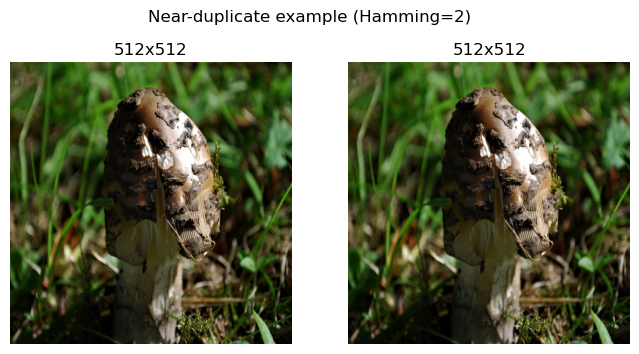

In [26]:
show_near_duplicate_example(df, pairs)

##### Summary

In [27]:
dup_counts = df["phash"].value_counts()
num_dup_hashes = (dup_counts > 1).sum()
num_dup_images = dup_counts[dup_counts > 1].sum()

print("Hashes that appear >1 time:", num_dup_hashes)
print("Images involved in duplicates:", num_dup_images)
print("Duplicate image rate:", num_dup_images / len(df))


Hashes that appear >1 time: 7622
Images involved in duplicates: 15636
Duplicate image rate: 0.15223296433682856


#### Sample Images per Class (visual sanity check)

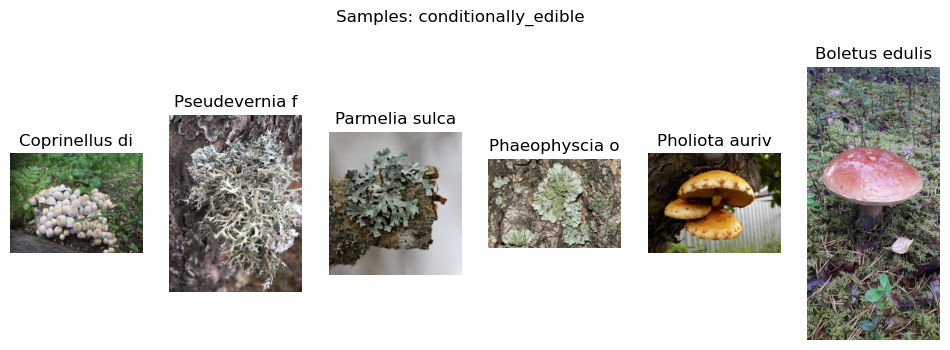

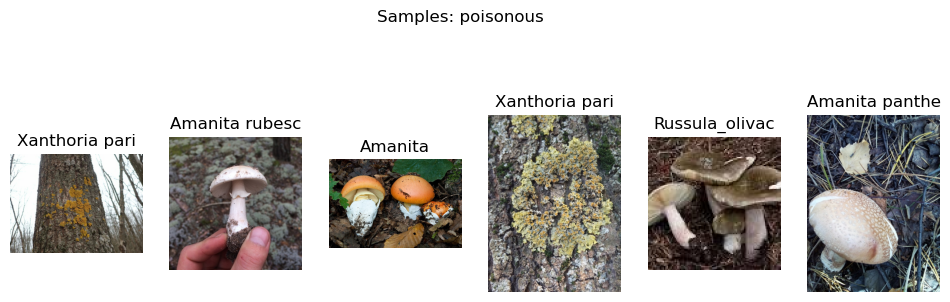

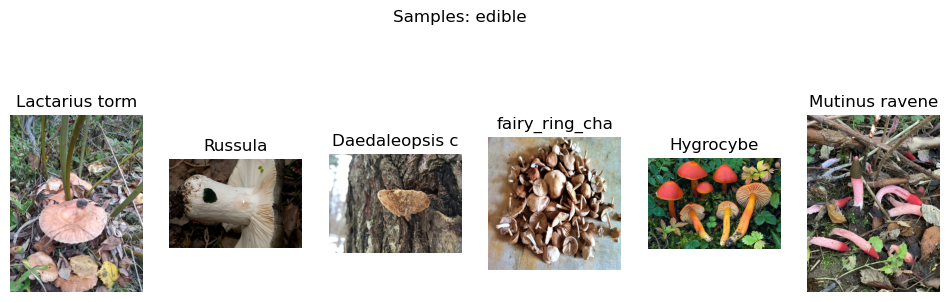

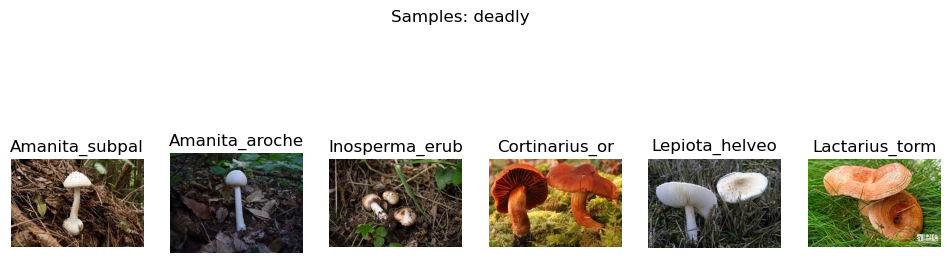

In [29]:
def show_samples(df, class_name, n=6, base_dir=CLASSES_DIR):
    sub = df[df["class"] == class_name].sample(n=min(n, len(df[df["class"] == class_name])), random_state=0)
    plt.figure(figsize=(12, 4))
    for i, (_, row) in enumerate(sub.iterrows(), start=1):
        plt.subplot(1, n, i)
        img = Image.open(base_dir / row["file_path"]).convert("RGB")
        plt.imshow(img)
        plt.axis("off")
        plt.title(row["species"][:14])
    plt.suptitle(f"Samples: {class_name}")
    plt.show()


for c in df["class"].unique():
    show_samples(df, c, n=6)

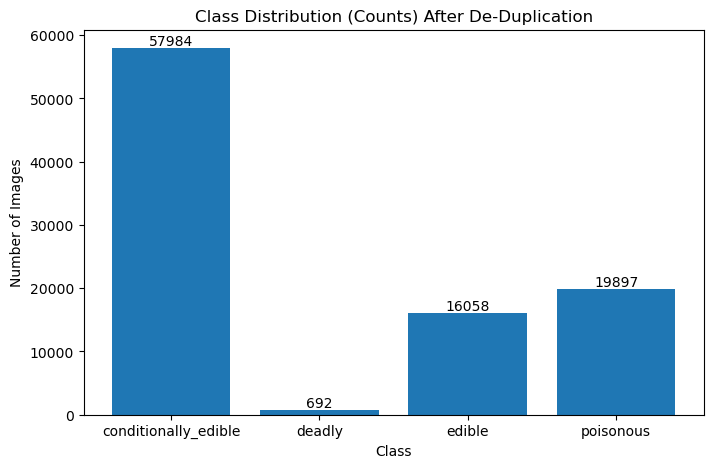

In [30]:
counts = near_dedup["class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values)

plt.title("Class Distribution (Counts) After De-Duplication")
plt.xlabel("Class")
plt.ylabel("Number of Images")

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.show()

In [31]:
near_dedup['class'].value_counts(normalize=True)

class
conditionally_edible    0.612738
poisonous               0.210259
edible                  0.169691
deadly                  0.007313
Name: proportion, dtype: float64

#### Handling Severe Class Imbalance

The **deadly** class represents less than 1% of the total dataset. Such extreme imbalance introduces several issues, such as:

* The model may fail to learn meaningful patterns from the **deadly** class as there are not enough images for training.
* Oversampling the minority class could lead to overfitting.
* Undersampling the majority classes will result in significantly less data available for training and testing.

Thus, we are going to combine the **deadly** class and the **poisonous** class into a single **toxic** category to improve class balance and model stability.

In [32]:
near_dedup['original_class'] = near_dedup['class']
near_dedup['class'] = near_dedup['class'].apply(lambda x: 'toxic' if x == 'poisonous' or x == 'deadly' else x)

In [33]:
near_dedup['class'].value_counts(normalize=True)

class
conditionally_edible    0.612738
toxic                   0.217571
edible                  0.169691
Name: proportion, dtype: float64

In [34]:
near_dedup['original_class'].value_counts(normalize=True)

original_class
conditionally_edible    0.612738
poisonous               0.210259
edible                  0.169691
deadly                  0.007313
Name: proportion, dtype: float64

In [35]:
near_dedup.to_csv(DATA_DIR / "mushroomDedupNearMerged.csv", index=False)